In [21]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg

from sklearn import mixture

In [32]:
dpgmm = mixture.BayesianGaussianMixture(
    n_components=3,
    covariance_type="full",
    weight_concentration_prior=1e-2,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)

In [3]:
import pandas as pd
table = pd.read_csv('./total_catalogues/w1_new_var_para_table1.csv')
print(len(table))
table = table[table['Mean']<16.5]
print(len(table))

30651661
15421630


In [24]:
print(table.columns)
print(len(table))

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id_in_matched', 'ra', 'dec', 'Mean',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita'],
      dtype='object')
15421630


In [23]:
print(max(table['id_in_matched']))

55575.0


In [25]:
X = np.array(table[['Mean',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
X

array([[16.36955621, 26.76546977,  0.67620942, ..., -2.04727833,
         0.86574534,  2.31259762],
       [16.11735956, 41.13851999,  1.58616157, ..., -0.31138504,
         0.85196104,  1.9796573 ],
       [16.48360116, 46.31895381,  1.89238653, ..., -0.53985777,
         0.82712798,  1.84762195],
       ...,
       [16.45167665, 24.6817203 ,  0.41865823, ..., -0.73906037,
         0.72087987,  1.95710133],
       [16.10711674, 30.62851157,  0.96737517, ..., -1.45040607,
         0.80599263,  1.76593718],
       [15.87716005, 14.14404375, -0.12437255, ...,  3.64120856,
         0.77411144,  1.31122357]])

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
X


array([[ 0.90662507, -0.00538492, -0.01036756, ..., -0.03306959,
         1.09070549,  0.79991537],
       [ 0.71003764, -0.00515269, -0.00987134, ...,  0.0506462 ,
         0.85296209,  0.09707605],
       [ 0.99552317, -0.00506899, -0.00970434, ...,  0.03962779,
         0.42465625, -0.18165147],
       ...,
       [ 0.970638  , -0.00541859, -0.01050801, ...,  0.03002098,
        -1.40784772,  0.04946024],
       [ 0.70205336, -0.0053225 , -0.01020878, ..., -0.00428462,
         0.06012635, -0.35408859],
       [ 0.52280198, -0.00558884, -0.01080414, ...,  0.24126534,
        -0.48974139, -1.31399217]])

In [33]:
dpgmm = dpgmm.fit(X)

In [34]:
Y = dpgmm.predict(X)

In [18]:
print(len(Y))

15421630


(array([13212083.,        0.,        0.,        0.,        0.,   248779.,
               0.,        0.,        0.,  1960768.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

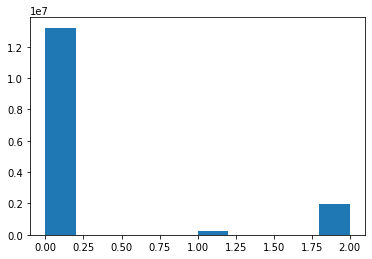

In [35]:
plt.hist(Y)

(array([ 1405485.,        0.,        0.,        0.,        0.,        0.,
               0.,        0.,        0., 14016145.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

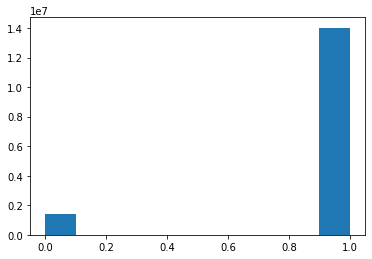

In [29]:
plt.hist(Y)

(array([ 2103348.,        0.,        0.,        0.,        0.,        0.,
               0.,        0.,        0., 13318282.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

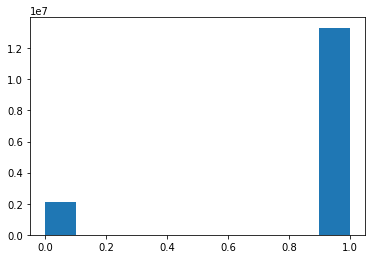

In [16]:
plt.hist(Y)

(array([12480497.,        0.,        0.,        0.,        0.,   378136.,
               0.,        0.,        0.,  2562997.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

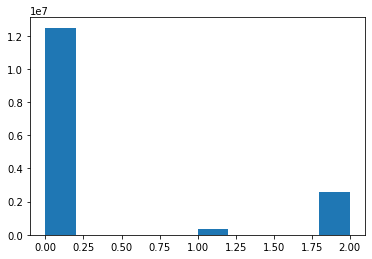

In [8]:
plt.hist(Y)

(array([  791630.,        0.,        0.,        0.,        0.,  5659619.,
               0.,        0.,        0., 24200412.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

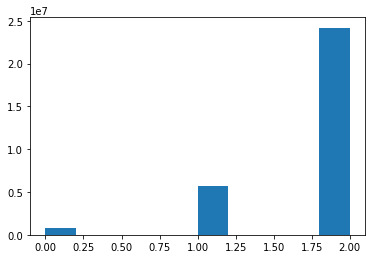

In [27]:
plt.hist(Y)

(array([15233084.,        0.,        0.,   480575.,        0.,        0.,
         3876087.,        0.,        0., 11337146.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

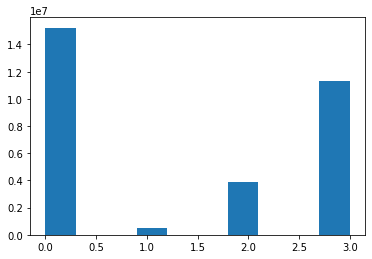

In [16]:
plt.hist(Y)

(array([ 1937116.,        0.,        0., 20729294.,        0.,        0.,
         7736132.,        0.,        0.,   249119.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

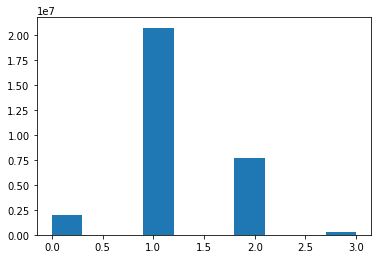

In [7]:
plt.hist(Y)

In [36]:
result_lists = []
for i in range(3):
    result_lists.append([])
ras = np.array(table['ra'])
decs = np.array(table['dec'])
ids = np.array(table['id_in_matched'])
for (i, label) in enumerate(Y):
    ra = ras[i]
    dec = decs[i]
    index = ids[i]
    if label == 0:
        result_lists[0].append((ra, dec, index))
    elif label == 1:
        result_lists[1].append((ra, dec, index))
    elif label == 2:
        result_lists[2].append((ra, dec, index))
    # elif label == 3:      
    #     result_lists[3].append((ra, dec, index)) 
    else:
        print("error")

In [37]:
for i in range(3):
    df = pd.DataFrame(result_lists[i])
    df.to_csv(f"./results/clustering_light_stand_3result_w1_table1_{i}.csv")
